In [30]:
import sys
print(sys.path)

['/usr/local/lib/python311.zip', '/usr/local/lib/python3.11', '/usr/local/lib/python3.11/lib-dynload', '', '/home/vscode/.local/lib/python3.11/site-packages', '/usr/local/lib/python3.11/site-packages', '/workspaces/Plasma', '/workspaces/Plasma']


In [31]:
import os
sys.path.append(os.path.abspath(".."))

In [32]:
import importlib
from resources import psiBfield

importlib.reload(psiBfield)

g = psiBfield.extract_g()
psi_norm, BR, Bphi, BZ = psiBfield.compute_B(g)

g_file keywords extracted
Psi Normalized and Magnetic field BR Bphi BZ computed.


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.optim as optim

In [34]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [35]:
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [36]:
g.r_grid

array([[0.84      , 0.84      , 0.84      , ..., 0.84      , 0.84      ,
        0.84      ],
       [0.85328125, 0.85328125, 0.85328125, ..., 0.85328125, 0.85328125,
        0.85328125],
       [0.8665625 , 0.8665625 , 0.8665625 , ..., 0.8665625 , 0.8665625 ,
        0.8665625 ],
       ...,
       [2.5134375 , 2.5134375 , 2.5134375 , ..., 2.5134375 , 2.5134375 ,
        2.5134375 ],
       [2.52671875, 2.52671875, 2.52671875, ..., 2.52671875, 2.52671875,
        2.52671875],
       [2.54      , 2.54      , 2.54      , ..., 2.54      , 2.54      ,
        2.54      ]], shape=(129, 129))

In [37]:
r = np.concatenate(g.r_grid)
print(r.shape)

(16641,)


In [38]:
z = np.concatenate(g.z_grid)
X_train = np.column_stack((r, z))


In [39]:
def plot(R ,Z, psi_preds, title):
  plt.contourf(R, Z, psi_preds,  cmap = 'plasma')
  plt.colorbar()
  plt.xlim([R[0],R[-1]])
  plt.ylim([Z[0],Z[-1]])
  plt.xlabel('R [m]')
  plt.ylabel('Z [m]')
  plt.axis('equal')
  plt.title(title)

In [40]:
# NN
class BZNN(nn.Module):
  def __init__(self):
    super(BZNN, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(2, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 1)

    )
  def forward(self, x):
    return self.model(x)

In [41]:
# Initialize model, loss, and optimizer
model_BZ = BZNN()
fn_Loss = nn.MSELoss()
model_BZ.to(device)
optimizer = optim.Adam(model_BZ.parameters(), lr=0.001)

In [42]:

BZ_train = np.concatenate(BZ)

In [43]:
BZ_train = BZ_train.reshape(-1,1)
print(BZ_train.shape, X_train.shape)

(16641, 1) (16641, 2)


In [44]:
X_train.dtype, BZ_train.dtype

(dtype('float64'), dtype('float64'))

In [45]:
# Move BR_train to the device as well
BZ_train = torch.tensor(BZ_train, dtype=torch.float32).to(device)
# Move X_train to the device as well
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)


# Training loop
epochs = 10001
for epoch in range(epochs):
  model_BZ.train()
  BZ_preds = model_BZ(X_train)
  loss = fn_Loss(BZ_preds, BZ_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch % 100 == 0:
    print(f"Epoch {epoch}, Loss: {loss.item()}")

Epoch 0, Loss: 0.12478839606046677
Epoch 100, Loss: 0.02675842121243477
Epoch 200, Loss: 0.020797129720449448
Epoch 300, Loss: 0.015590537339448929
Epoch 400, Loss: 0.01172089483588934
Epoch 500, Loss: 0.009136934764683247
Epoch 600, Loss: 0.007516129408031702
Epoch 700, Loss: 0.00656198151409626
Epoch 800, Loss: 0.005513054318726063
Epoch 900, Loss: 0.02324981428682804
Epoch 1000, Loss: 0.004722826648503542
Epoch 1100, Loss: 0.005244224797934294
Epoch 1200, Loss: 0.0042128427885472775
Epoch 1300, Loss: 0.00560505036264658
Epoch 1400, Loss: 0.0038296470884233713
Epoch 1500, Loss: 0.0037326884921640158
Epoch 1600, Loss: 0.003552848706021905
Epoch 1700, Loss: 0.003440572414547205
Epoch 1800, Loss: 0.004931172356009483
Epoch 1900, Loss: 0.003191253636032343
Epoch 2000, Loss: 0.0031046730000525713
Epoch 2100, Loss: 0.0032825255766510963
Epoch 2200, Loss: 0.0029037732165306807
Epoch 2300, Loss: 0.003909956198185682
Epoch 2400, Loss: 0.0026786273811012506
Epoch 2500, Loss: 0.0025891857221722

In [46]:
# Testing



In [47]:
# Compute final MSE loss
model_BZ.eval()
with torch.no_grad():
  BZ_final = model_BZ(X_train)
  loss = fn_Loss(BZ_final, BZ_train)
  loss_BZ = loss.item() * 100
  print(f"Final MSE Loss for (R, Z) -> BZ (in %): {loss_BZ}")

Final MSE Loss for (R, Z) -> BZ (in %): 0.017497935914434493


In [ ]:
BZ_final = BZ_final.reshape(129,129)

In [58]:
BZ_final.dtype, BZ.dtype

(torch.float32, dtype('float64'))

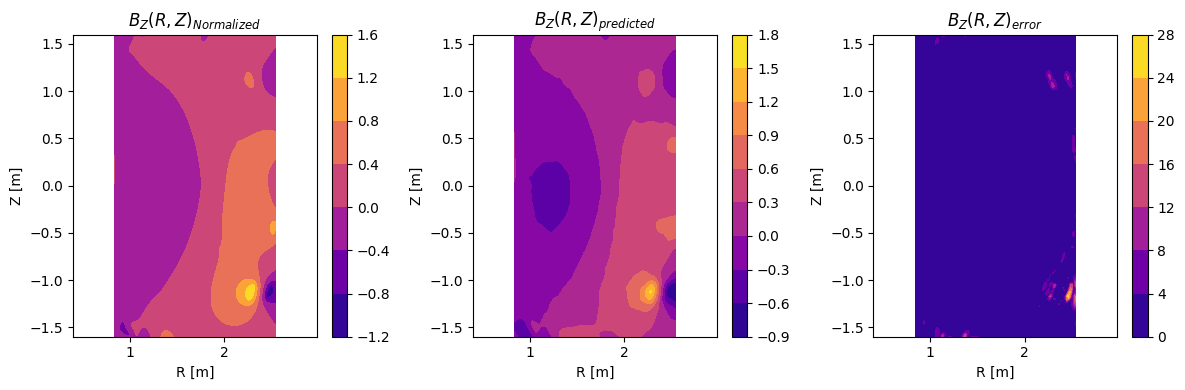

In [59]:
fig = plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plot(g.r_grid[:, 0] ,g.z_grid[0, :], BZ.T, title = r"$B_{Z}(R,Z)_{Normalized}$")

plt.subplot(1,3,2)
plot(g.r_grid[:, 0] ,g.z_grid[0, :], BZ_final.detach().numpy().T, title = r"$B_{Z}(R,Z)_{predicted}$")

plt.subplot(1,3,3)
plot(g.r_grid[:, 0], g.z_grid[0, :], (abs(BZ-BZ_final.detach().numpy())*100).T, title=r"$B_{Z}(R, Z)_{error}$")

plt.tight_layout()
plt.show()